In [75]:
import numpy as np
import random
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams.update({'font.size': 12})

- Kaj sploh naloga zahteva od nas?

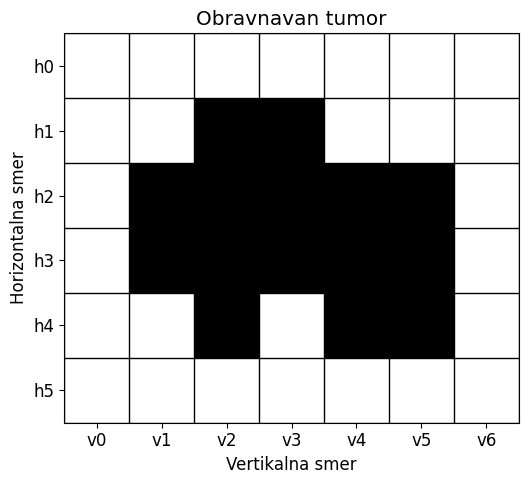

In [76]:
cells = [
    [False, False, False, False, False, False, False],
    [False, False, True,  True,  False, False, False],
    [False, True,  True,  True,  True,  True,  False],
    [False, True,  True,  True,  True,  True,  False],
    [False, False, True,  False, True,  True,  False],
    [False, False, False, False, False, False, False]
]

cells = np.array(cells, dtype=int)  # Convert to 0/1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cells, cmap='Greys', interpolation='none', origin='upper')

# Axis labeling
ax.set_xticks(np.arange(cells.shape[1]))
ax.set_yticks(np.arange(cells.shape[0]))
ax.set_xticklabels([f"v{j}" for j in range(cells.shape[1])])
ax.set_yticklabels([f"h{i}" for i in range(cells.shape[0])])

# Grid lines to match cell boundaries
ax.set_xticks(np.arange(-0.5, cells.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, cells.shape[0], 1), minor=True)
ax.grid(which='minor', color='black', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

plt.xlabel("Vertikalna smer")
plt.ylabel("Horizontalna smer")
plt.title("Obravnavan tumor")
plt.tight_layout()
plt.show()


## Modelske funkcije in osnovna vizualizacija

In [77]:
def attenuation(i, j, model):
    """
    Vrne oslabitveni faktor za dozo v celici (i, j) glede na izbrani model.

    Parameters:
        i (int): vrstica (za vertikalne žarke)
        j (int): stolpec (za horizontalne žarke)
        mu (float): koeficient pojemanja (za eksponentni model)
        model (str): "none" | "exp" | "proton"

    Returns:
        tuple: (horizontal_attenuation, vertical_attenuation)
    """
    
    if model == "none":
        return 1.0, 1.0
    
    elif model == "exp":
        mu = 0.05
        return np.exp(-mu * j), np.exp(-mu * i)
    
    elif model == "proton": #### TO NI OK - bo treba spisat posebaj za protonsko terapijo
        # Preprost približek Braggovega vrha – največja doza na določeni globini
        def bragg(depth, peak=2):
            if depth < peak:
                return (depth / peak) ** 2
            else:
                return np.exp(-3 * (depth - peak))
        return bragg(j), bragg(i)
    
    else:
        raise ValueError(f"Neznan model pojemanja: {model}")


def optimize_dose(cells, mode, atten_model):
    """
    Optimizira razporeditev žarkov v radioterapiji.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor, False = zdravo)
        mode (int):
            1 - tumor ≥ 1, zdravo minimalno (minimiziraj dozo v zdravih celicah)
            2 - zdravo ≤ 1, tumor maksimalno (maksimiziraj dozo v tumorskih celicah)
        atten_model (str): Model pojemanja žarkov:
            "none"   - brez pojemanja (vse celice prejmejo enako moč žarka)
            "exp"    - eksponentno pojemanje z razdaljo (modelira rentgensko terapijo)
            "proton" - pojemanje z Braggovim vrhom (modelira protonsko terapijo)

    Returns:
        result (scipy.optimize.OptimizeResult): Rezultat optimizacije, ki vsebuje npr.:
            - result.success (bool): ali je optimizacija uspela
            - result.x (ndarray): optimalne vrednosti žarkov (najprej horizontalni, nato vertikalni)
        dose_grid (2D ndarray of float): Matrika (oblika enaka kot cells), ki vsebuje
            izračunano skupno dozo, ki jo prejme vsaka celica, ob upoštevanju pojemanja.
    """

    cells = np.array(cells)
    n_rows, n_cols = cells.shape
    n_vars = n_rows + n_cols  # h0...hn-1, v0...vm-1

    A = []
    b = []
    c = np.zeros(n_vars)

    for i in range(n_rows):
        for j in range(n_cols):
            h_att, v_att = attenuation(i, j, model=atten_model)
            row = np.zeros(n_vars)
            row[i] = h_att
            row[n_rows + j] = v_att

            if mode == 1:
                if cells[i, j]:  # tumor
                    A.append(-row)
                    b.append(-1)
                else:
                    c[i] += h_att
                    c[n_rows + j] += v_att
                    
            elif mode == 2:
                if cells[i, j]:  # tumor
                    c[i] -= h_att
                    c[n_rows + j] -= v_att
                else:
                    A.append(row)
                    b.append(1)

    bounds = [(0, 1.)] * n_vars
    result = linprog(c=c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # ⬇️ Compute actual dose matrix using attenuation
    dose_grid = np.zeros((n_rows, n_cols))
    if result.success:
        h_vals = result.x[:n_rows]
        v_vals = result.x[n_rows:]
        for i in range(n_rows):
            for j in range(n_cols):
                h_att, v_att = attenuation(i, j, model=atten_model)
                dose_grid[i, j] = h_vals[i] * h_att + v_vals[j] * v_att

    return result, dose_grid


def visualize_dose(cells, dose_grid):
    """
    Prikaže toplotno karto (heatmap) doz po mreži celic, z obrobo in šrafuro okrog tumorskih celic.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor)
        dose_grid (2D array): Matrika prejete doze po celicah
    """
    cells = np.array(cells)
    n_rows, n_cols = cells.shape

    fig, ax = plt.subplots(figsize=(8, 5))
    c = ax.imshow(dose_grid, cmap='Reds', interpolation='nearest')

    # Dodaj obrobe in šrafuro za tumorske celice
    for i in range(n_rows):
        for j in range(n_cols):
            if cells[i, j]:  # tumor
                rect = patches.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    linewidth=2,
                    edgecolor='black',
                    facecolor='none',
                    hatch='O',
                    alpha=1
                )
                ax.add_patch(rect)

    # Dodaj vrednosti v celice
    for i in range(n_rows):
        for j in range(n_cols):
            val = f"{dose_grid[i, j]:.2f}"
            ax.text(j, i, val, ha='center', va='center', color='cyan', fontsize=8)

    ax.set_title("Doze sevanja")
    plt.colorbar(c, label="Doza")
    plt.xticks(np.arange(n_cols), labels=[f"v{j}" for j in range(n_cols)])
    plt.yticks(np.arange(n_rows), labels=[f"h{i}" for i in range(n_rows)])
    plt.xlabel("Vertikalna smer")
    plt.ylabel("Horizontalna smer")
    plt.tight_layout()
    plt.show()


- To kar naloga zahteva od nas

Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimalna vrednost: -25.0
Horizontalni žarki (h): [0. 0. 1. 1. 0. 0.]
Vertikalni žarki (v): [0. 1. 1. 1. 1. 1. 0.]


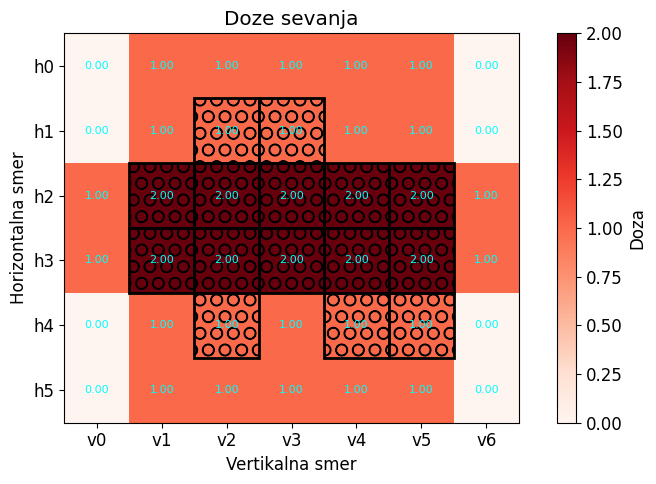

In [78]:
cells = [
    [False, False, False, False, False, False, False],
    [False, False, True,  True,  False, False, False],
    [False, True,  True,  True,  True,  True,  False],
    [False, True,  True,  True,  True,  True,  False],
    [False, False, True,  False, True,  True,  False],
    [False, False, False, False, False, False, False]
]

res, dose_grid = optimize_dose(cells, mode=2, atten_model="none")

print("Status:", res.message)
print("Optimalna vrednost:", res.fun)

# Razbij spremenljivke na h in v
n_rows = len(cells)
n_cols = len(cells[0])

h = res.x[:n_rows]
v = res.x[n_rows:]

print("Horizontalni žarki (h):", h)
print("Vertikalni žarki (v):", v)

visualize_dose(cells, dose_grid)

- Povprečne prejete doze tumornih in zdravih celic v 15 celičnem tumorju

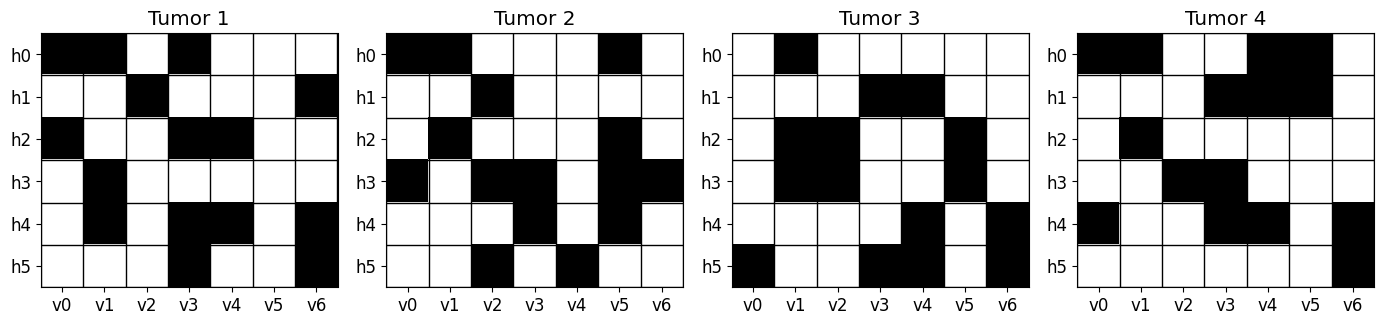

In [79]:
def generate_random_tumor(rows, cols, tumor_size):
    """
    Generate a grid of shape (rows, cols) with exactly `tumor_size` True values placed randomly.
    """
    total_cells = rows * cols
    flat = np.zeros(total_cells, dtype=int)
    flat[np.random.choice(total_cells, tumor_size, replace=False)] = 1
    return flat.reshape((rows, cols))

# Parameters
rows, cols = 6, 7
tumor_size = 15
num_tumors = 4

# Generate random tumors
tumors = [generate_random_tumor(rows, cols, tumor_size) for _ in range(num_tumors)]

# Plot
fig, axes = plt.subplots(1, num_tumors, figsize=(14, 4))
for idx, (ax, tumor) in enumerate(zip(axes, tumors)):
    im = ax.imshow(tumor, cmap='Greys', interpolation='none', origin='upper')
    ax.set_xticks(np.arange(cols))
    ax.set_yticks(np.arange(rows))
    ax.set_xticklabels([f"v{j}" for j in range(cols)])
    ax.set_yticklabels([f"h{i}" for i in range(rows)])
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.set_title(f"Tumor {idx+1}")

plt.tight_layout()
plt.show()


In [92]:
def generate_random_tumor_mask(tumor_count, rows=6, cols=7):
    """
    Ustvari naključni tumor velikosti tumor_count

    Parameters:
        tumor_count(int): Število tumorskih celic v matriki
        rows(int): Število vrstic v matriki
        cols(int): Število stolpcev v matriki
    
    Returns:
        random_tumor(np.array): Naključen tumor velikosti tumor count
    """

    total_cells = rows * cols
    indices = random.sample(range(total_cells), tumor_count)
    mask = np.zeros(total_cells, dtype=bool)
    mask[indices] = True
    random_tumor = mask.reshape((rows, cols))

    return random_tumor


def simulate_distributions(tumor_count, n_simulations, mode, atten_model, tumor):
    """
    Pridobi porazdelitve obsevanja zdravih celic za tumor velikosti tumor_count

    Parameters:
        tumor_count(int): Število tumorskih celic v matriki
        n_simulations(int): Število simulacij z različnimi tumorji enake velikosti tumor_count

    Returns:
        values: Vrednosti obsevanja zdravih celic
        num: povprečno stevilo prizganih kanalov
    """
    
    values_list = []
    num = 0
    num_h = 0
    num_v = 0

    for _ in range(n_simulations):
        tumor_mask = generate_random_tumor_mask(tumor_count)
        result, dose_grid = optimize_dose(tumor_mask, mode, atten_model)
        # visualize_dose(tumor_mask, dose_grid)
        if result.success:
            if tumor == True:
                healthy_mask = tumor_mask
            else:
                healthy_mask = ~tumor_mask
            healthy_doses = dose_grid[healthy_mask]
            values_list.append(healthy_doses)
            h_vals = result.x[:n_rows]
            v_vals = result.x[n_rows:]
            num += np.count_nonzero(result.x)
            num_h += np.count_nonzero(h_vals)
            num_v += np.count_nonzero(v_vals)

    num = num / n_simulations
    num_h = num_h / n_simulations
    num_v = num_v / n_simulations
    values = np.concatenate(values_list)
    
    return values, num, num_h, num_v


def plot_healthy_dose_histogram(values1, values2, bin_width=0.05, tumor=False):

    bins = np.arange(0, max(values1.max(), values2.max()) + 2 * bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(values1, bins=bins, edgecolor='black', color='blue', alpha=0.5, label='Način 1')
    ax.hist(values2, bins=bins, edgecolor='black', color='red', alpha=0.5, label='Način 2')

    # Navpična črta pri x = 1
    ax.axvline(x=1, color='black', linestyle='solid', linewidth=1.5)

    # Koordinati za začetek in konec puščice
    y_level = ax.get_ylim()[1] * 0.85
    x_start = 1
    x_end = 1.3

    # Narišemo puščico posebej
    ax.annotate(
        '',  # prazno besedilo
        xy=(x_end, y_level), xytext=(x_start, y_level),
        arrowprops=dict(arrowstyle='->', color='black')
    )

    # Narišemo tekst posebej
    ax.text(x_end - 0.2, y_level*1.05, 'nadkritična doza', va='center', fontsize=10)

    # Izračun povprečij
    avg1 = values1.mean()
    avg2 = values2.mean()

    # Izračun deleža vrednosti >= 1 (v odstotkih)
    frac1 = 100 * np.sum(values1 >= 1) / len(values1)
    frac2 = 100 * np.sum(values2 >= 1) / len(values2)

    # Priprava besedil za textboxe
    textstr1 = '\n'.join((
        r'$\langle D \rangle_{\mathrm{način\ 1}} = %.3f$' % avg1,
        r'$\langle D \rangle_{\mathrm{način\ 2}} = %.3f$' % avg2,
    ))

    textstr2 = '\n'.join((
        r'$D \geq 1$: ',
        f'Način 1: {frac1:.1f} %',
        f'Način 2: {frac2:.1f} %',
    ))

    # Dodamo textbox z povprečji (zgornji desni kot)
    ax.text(0.98, 0.95, textstr1, transform=ax.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))

    # Dodamo še textbox z deleži (spodaj desno)
    ax.text(0.98, 0.75, textstr2, transform=ax.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))
    
    if tumor==True:
        title = "tumornih"
    else:
        title = "zdravih"
    
    ax.set_title(f"Porazdelitev doz {title} celic")
    ax.set_xlabel("Prejeta doza")
    ax.set_ylabel("Število celic")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    fig.tight_layout()
    plt.show()


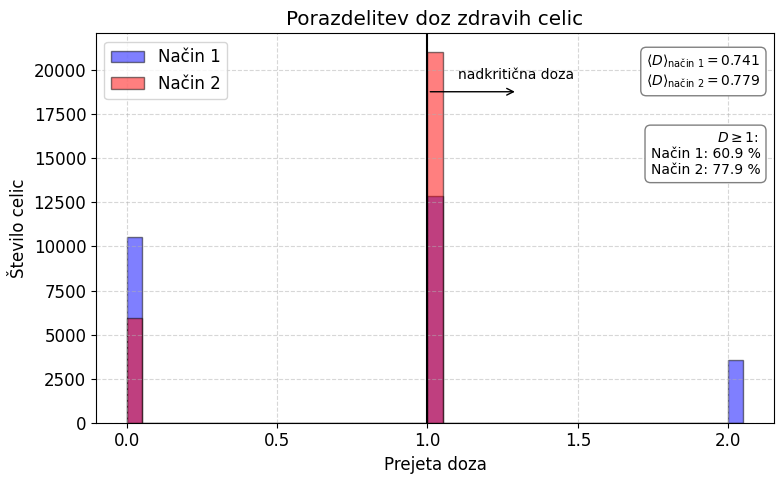

5.846
2.816
3.03
----
5.746
3.284
2.462


In [96]:
tumor = False
values1, num1, num_h1, num_v1 = simulate_distributions(tumor_count=15, n_simulations=1000, mode=1, atten_model="none", tumor=tumor)
values2, num2, num_h2, num_v2 = simulate_distributions(tumor_count=15, n_simulations=1000, mode=2, atten_model="none", tumor=tumor)
plot_healthy_dose_histogram(values1, values2, tumor=tumor)
print(num1)
print(num_h1)
print(num_v1)
print('----')
print(num2)
print(num_h2)
print(num_v2)

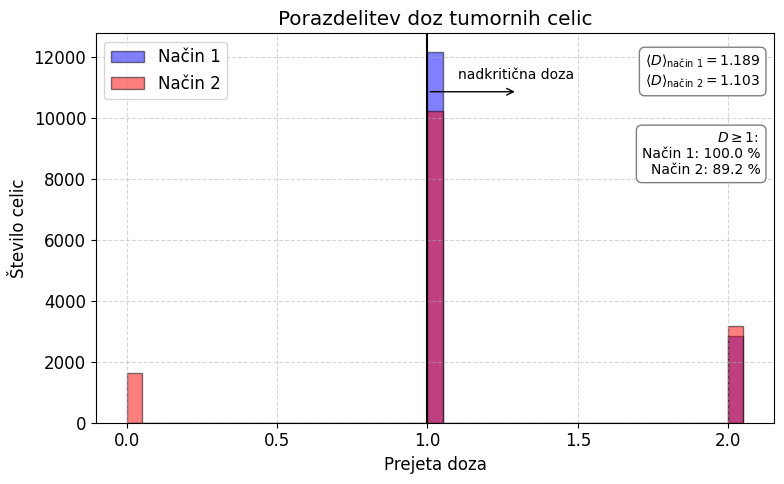

5.838
2.806
3.032
----
5.747
3.407
2.34


In [97]:
tumor = True
values1, num1, num_h1, num_v1 = simulate_distributions(tumor_count=15, n_simulations=1000, mode=1, atten_model="none", tumor=tumor)
values2, num2, num_h2, num_v2 = simulate_distributions(tumor_count=15, n_simulations=1000, mode=2, atten_model="none", tumor=tumor)
plot_healthy_dose_histogram(values1, values2, tumor=tumor)
print(num1)
print(num_h1)
print(num_v1)
print('----')
print(num2)
print(num_h2)
print(num_v2)

Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimalna vrednost: -17.0
Horizontalni žarki (h): [1. 1. 0. 1. 1. 0.]
Vertikalni žarki (v): [-0. -0.  1. -0. -0. -0. -0.]


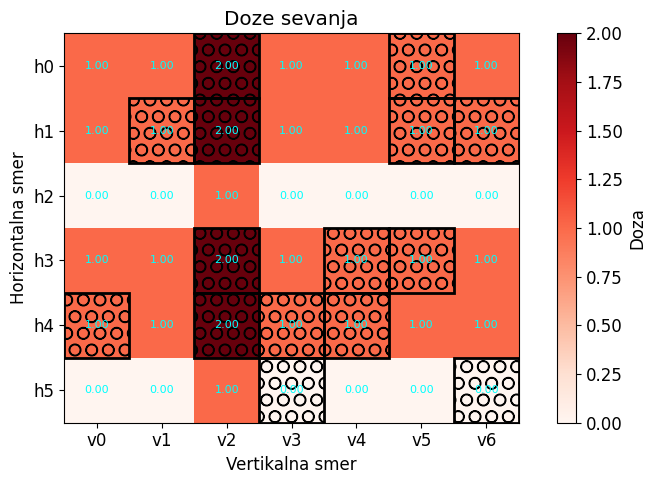

In [90]:
rows, cols = 6, 7
tumor_size = 15
cells = generate_random_tumor(rows, cols, tumor_size)

res, dose_grid = optimize_dose(cells, mode=2, atten_model="none")

print("Status:", res.message)
print("Optimalna vrednost:", res.fun)

# Razbij spremenljivke na h in v
n_rows = len(cells)
n_cols = len(cells[0])

h = res.x[:n_rows]
v = res.x[n_rows:]

print("Horizontalni žarki (h):", h)
print("Vertikalni žarki (v):", v)

visualize_dose(cells, dose_grid)

- Povprečna prejeta doza zdravih in tumornih celic v odvisnosti od velikosti tumorja

In [ ]:
tumor_counts = np.arange(1, rows*cols)
print(tumor_counts)

avg_z1 = np.zeros_like(tumor_counts)
num_z1 = np.zeros_like(tumor_counts)
avg_z2 = np.zeros_like(tumor_counts)
num_z2 = np.zeros_like(tumor_counts)
avg_t1 = np.zeros_like(tumor_counts)
num_t1 = np.zeros_like(tumor_counts)
avg_t2 = np.zeros_like(tumor_counts)
num_t2 = np.zeros_like(tumor_counts)

for i, tumor_count in enumerate(tumor_counts):
    print(i)
    values_z1, num1, num_h1, num_v1 = simulate_distributions(tumor_count=tumor_count, n_simulations=1000, mode=1, atten_model="none", tumor=False)
    values_z2, num2, num_h2, num_v2 = simulate_distributions(tumor_count=tumor_count, n_simulations=1000, mode=2, atten_model="none", tumor=False)
    values_t1, num1, num_h1, num_v1 = simulate_distributions(tumor_count=tumor_count, n_simulations=1000, mode=1, atten_model="none", tumor=True)
    values_t2, num2, num_h2, num_v2 = simulate_distributions(tumor_count=tumor_count, n_simulations=1000, mode=2, atten_model="none", tumor=True)

    # Izračun povprečij
    avg_z1[i] = values_z1.mean()
    avg_z2[i] = values_z2.mean()
    avg_t1[i] = values_t1.mean()
    avg_t2[i] = values_t2.mean()

    # Izračun deleža vrednosti >= 1 (v odstotkih)
    num_z1[i] = 100 * np.sum(values_z1 >= 1) / len(values_z1)
    num_z2[i] = 100 * np.sum(values_z2 >= 1) / len(values_z2)
    num_t1[i] = 100 * np.sum(values_t1 >= 1) / len(values_t1)
    num_t2[i] = 100 * np.sum(values_t2 >= 1) / len(values_t2)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41]
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


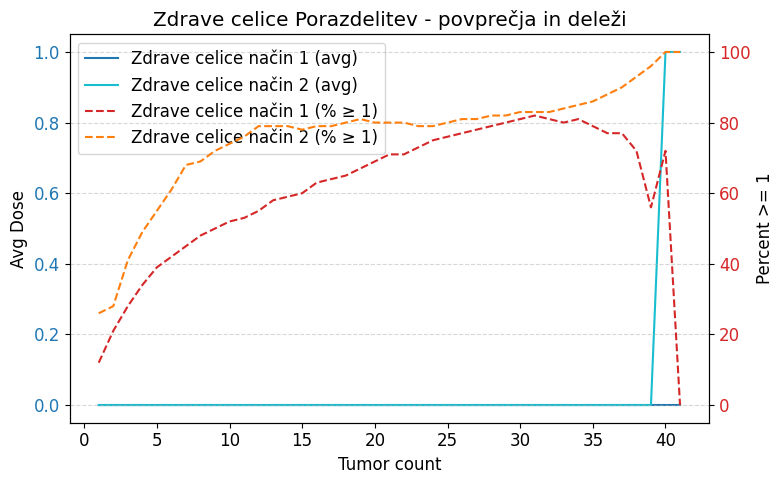

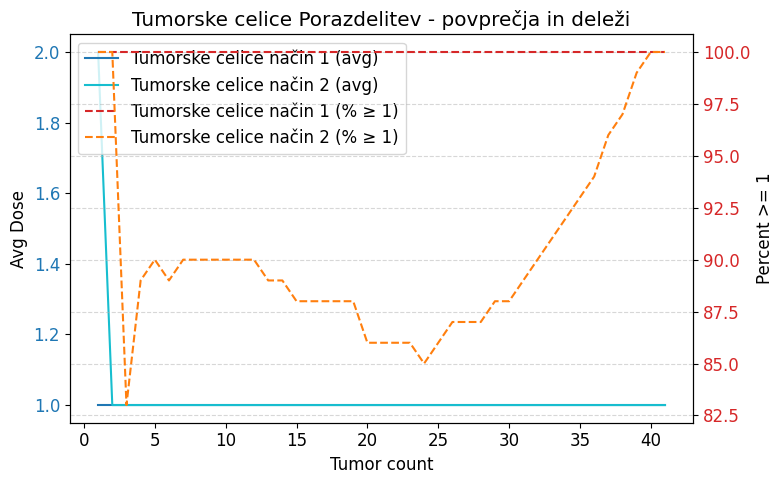

In [102]:
def plot_avg_num(tumor_counts, avg1, avg2, num1, num2, title_avg='Avg Dose', title_num='Percent >= 1', prefix=''):
    fig, ax1 = plt.subplots(figsize=(8,5))

    color_avg1 = 'tab:blue'
    color_avg2 = 'tab:cyan'
    color_num1 = 'tab:red'
    color_num2 = 'tab:orange'

    # Left y-axis: avg
    ax1.set_xlabel('Tumor count')
    ax1.set_ylabel(title_avg)
    l1 = ax1.plot(tumor_counts, avg1, label=f'{prefix} način 1 (avg)', color=color_avg1)
    l2 = ax1.plot(tumor_counts, avg2, label=f'{prefix} način 2 (avg)', color=color_avg2)
    ax1.tick_params(axis='y', labelcolor=color_avg1)

    # Right y-axis: num (percent >=1)
    ax2 = ax1.twinx()
    ax2.set_ylabel(title_num)
    l3 = ax2.plot(tumor_counts, num1, label=f'{prefix} način 1 (% ≥ 1)', color=color_num1, linestyle='--')
    l4 = ax2.plot(tumor_counts, num2, label=f'{prefix} način 2 (% ≥ 1)', color=color_num2, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color_num1)

    # Combine legends from both axes
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.title(f'{prefix} Porazdelitev - povprečja in deleži')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Plot for _z data
plot_avg_num(tumor_counts, avg_z1, avg_z2, num_z1, num_z2, prefix='Zdrave celice')

# Plot for _t data
plot_avg_num(tumor_counts, avg_t1, avg_t2, num_t1, num_t2, prefix='Tumorske celice')